In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import scipy.sparse as sp
from scipy.special import iv 
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

class SpectralBasisGenerator:
    """
    Computes Chebyshev approximated Wavelets for a given Adjacency Matrix.
    """
    def __init__(self, adj_matrix, s=1.0):
        # Input adj_matrix should be unweighted/binary as per paper 
        self.adj = adj_matrix
        self.n_nodes = adj_matrix.shape[0]
        self.s = s 
        self.L = self._compute_normalized_laplacian()

    def _compute_normalized_laplacian(self):
        # L = I - D^{-1/2} A D^{-1/2}
        row_sum = np.array(self.adj.sum(1))
        d_inv_sqrt = np.power(row_sum, -0.5).flatten()
        d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.
        d_mat_inv_sqrt = sp.diags(d_inv_sqrt)
        A_norm = d_mat_inv_sqrt @ self.adj @ d_mat_inv_sqrt
        return sp.eye(self.n_nodes) - A_norm

    def get_chebyshev_wavelets(self, order_M=3):
        # Approximates Wavelets using Chebyshev Polynomials max degree set by order_M to 3
        # Psi_s approx sum(c_i * T_i(L_tilde)) 
        
        # 1. Rescale L to [-1, 1]: L_tilde = (2/lambda_max)*L - I
        # We approximate lambda_max ~ 2.0 so 2/lambda_max * L is ~ L     
        L_tilde = self.L - sp.eye(self.n_nodes) # normalised Laplacian take away identity

        # 2. Coefficients c_i based on Bessel functions
        c_i = [2 * np.exp(-self.s)* iv(i, self.s) for i in range(order_M + 1)]
        # gives c_0, c_1 ... c_M


        # 3. Recurrence: T_0=I, T_1=L_tilde, T_k = 2*L_tilde*T_{k-1} - T_{k-2}
        T_k = [sp.eye(self.n_nodes), L_tilde] # T_k = [T0, T1]
        Psi = 0.5 * c_i[0] *T_k[0] + c_i[1] * T_k[1] # this is 0.5 c_0 + c_1*T_k1
        
        for k in range(2, order_M + 1):
            T_new = 2 * L_tilde @ T_k[-1] - T_k[-2] # T_k = 2*L_tilde*T_{k-1} - T_{k-2}
            T_k.append(T_new)
            Psi += c_i[k] * T_new # adds rest of terms in sum of T_ki * c_i
        return torch.FloatTensor(Psi.toarray())    
        #return torch.from_numpy(np.asarray(Psi)).float()

class SpGATLayer(nn.Module):
    """
    SpGAT Layer adapted for dynamic graphs (basis passed in forward).
    """
    def __init__(self, in_features, out_features, d_proportion=0.15):
        super().__init__()
        self.d_prop = d_proportion
        self.theta = nn.Linear(in_features, out_features, bias=False) # Shared theta
        self.activation = nn.ReLU()
        
        # We initialize attention weights for a specific max size, 
        # or dynamically resize. For simplicity/efficiency in dynamic graphs, 
        # we define a large enough parameter vector and slice it, 
        # or learn a projection. Here we use a learnable scalar vector 
        # projected to the current graph size for stability.
        # Paper uses fixed diagonal matrices, assuming fixed N.
        # ADAPTATION: We will learn two global vectors and interpolate to current N 
        # to handle changing N_nodes per day.
        self.att_L_proto = nn.Parameter(torch.ones(1000)) # Reservoir
        self.att_H_proto = nn.Parameter(torch.ones(1000)) # not sure about two separate vectors

    def forward(self, x, basis_matrix):
        N = basis_matrix.shape[0]
        d = int(N * self.d_prop)
        
        # 1. Feature Transform: X = H Theta [cite: 110]
        x_trans = self.theta(x)
        
        # 2. Split Basis
        B_L = basis_matrix[:, :d]
        B_H = basis_matrix[:, d:]
        
        # 3. Dynamic Attention Weights (Interpolated to current N)
        # We slice or interpolate the learnable parameters to fit current d / N-d
        a_L = F.softmax(self.att_L_proto[:d], dim=0) # Attention weights for low freq
        a_H = F.softmax(self.att_H_proto[:(N-d)], dim=0) # Attention weights for high freq
        
        diag_a_L = torch.diag(a_L) # diag 
        diag_a_H = torch.diag(a_H)
        
        # 4. Convolution: B * Att * B^T * X
        out_L = (B_L @ diag_a_L @ B_L.t()) @ x_trans
        out_H = (B_H @ diag_a_H @ B_H.t()) @ x_trans
        
        # 5. Aggregation (Sum)
        return self.activation(out_L + out_H)

In [4]:
class SpectralBubbleModel(nn.Module):
    def __init__(self, feature_dim, embedding_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # 1. SpGAT Encoder (Replaces Diffusion + GAT)
        # Input: Combined features + Initial embeddings
        in_dim = feature_dim + embedding_dim 
        self.spgat = SpGATLayer(in_dim, hidden_dim, d_proportion=0.15)
        
        # 2. GRU Cell (Standard, taking SpGAT output)
        self.gru_cell = nn.GRUCell(hidden_dim, hidden_dim)
        
        # 3. Decoder (Reconstruction)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feature_dim)
        )
        
        self.dropout = nn.Dropout(dropout)

    def forward(self, X_t, H_t, basis_matrix, h_prev):
        # Concatenate Raw Features and Embeddings
        # X_in: (N, feature_dim + embedding_dim)
        X_in = torch.cat([X_t, H_t], dim=1)
        
        # 1. Spectral Convolution (The "Wavelet Method")
        # Explicitly captures global patterns via spectral domain
        z_t = self.spgat(X_in, basis_matrix) # (N, hidden_dim)
        z_t = self.dropout(z_t)
        
        # 2. Temporal Update
        h_t = self.gru_cell(z_t, h_prev)
        
        # 3. Reconstruction
        X_hat = self.decoder(h_t)
        
        # 4. Anomaly Scoring (Feature Reconstruction Error)
        loss_vec = torch.norm(X_t - X_hat, dim=1)
        
        # Bubble signal (MinMax scaled per batch for visibility)
        signals = (loss_vec - loss_vec.min()) / (loss_vec.max() - loss_vec.min() + 1e-8)
        #signals = loss_vec
        return h_t, signals, torch.mean(loss_vec**2)

In [5]:
import pandas as pd
def compute_initial_node_embeddings(returns, t, K, eps=0.0, active=None):
    node_embeddings = {}
    t = pd.to_datetime(t)
    windowed_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t].dropna(how='all')
    
    # Check if window is empty
    if windowed_returns.empty:
        return {}, []

    window = windowed_returns.dropna(axis=1, how="all")
    if active is not None:
        # Intersect active with available columns
        valid_active = [c for c in active if c in window.columns]
        if not valid_active:
            return {}, []
        window = window[valid_active]
        
    if window.shape[0] < 2 or window.shape[1] == 0: # Need at least some data
        return {}, []

    if eps == 0.0:
        window = window.loc[:, ~(window.fillna(0.0) == 0.0).all(axis=0)]
    else:
        window = window.loc[:, ~(window.fillna(0.0).abs() <= eps).all(axis=0)]

    active_cols = window.columns.tolist()
    if not active_cols:
        return {}, []

    U, S, Vt = np.linalg.svd(window.values, full_matrices=False)
    V = Vt.T
    H = V @ np.diag(S)
    H = H[:, :10]

    # Handle case where SVD returns fewer than 10 components
    if H.shape[1] < 10:
        padding = np.zeros((H.shape[0], 10 - H.shape[1]))
        H = np.hstack([H, padding])
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    H = scaler.fit_transform(H)

    for i, stock in enumerate(active_cols):
        node_embeddings[stock] = H[i, :] # contains only one embedding per stock at time t, embedding shape (10,)
        
    # here - store the array directly in the list to match our structure
    for stock in node_embeddings:
        node_embeddings[stock] = np.array(node_embeddings[stock])
        
    return node_embeddings, active_cols

def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]

    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    active = window.columns[ok_obs & ok_nonzero].tolist()

    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)
        
        active = list(active_set)

    return active

In [6]:

def prepare_node_features(stocks, sectors, volatility, market_caps, pe_ratios, implied_vol, short_interest,
                           beta, operating_margin, return_on_equity, rsi_momentum, turnover, t):

    rows = []
    t = pd.to_datetime(t)
    if not stocks:
        return torch.empty((0, 2), dtype=torch.float32)
    for stock in stocks:
        # Get factors for stock at time t (or default values if missing)
        sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
        market_cap = market_caps.loc[t, stock] if t in market_caps.index and stock in market_caps.columns else 0.0
        pe_ratio = pe_ratios.loc[t, stock] if t in pe_ratios.index and stock in pe_ratios.columns else 0.0
        implied_volatility = implied_vol.loc[t, stock] if t in implied_vol.index and stock in implied_vol.columns else 0.0
        short_int = short_interest.loc[t, stock] if t in short_interest.index and stock in short_interest.columns else 0.0
        beta_val = beta.loc[t, stock] if t in beta.index and stock in beta.columns else 0.0
        op_margin = operating_margin.loc[t, stock] if t in operating_margin.index and stock in operating_margin.columns else 0.0
        roe = return_on_equity.loc[t, stock] if t in return_on_equity.index and stock in return_on_equity.columns else 0.0
        rsi = rsi_momentum.loc[t, stock] if t in rsi_momentum.index and stock in rsi_momentum.columns else 0.0
        turn = turnover.loc[t, stock] if t in turnover.index and stock in turnover.columns else 0.0

        # Get volatility at time t (or nearest available)
        if t in volatility.index and stock in volatility.columns:
            vol = volatility.loc[t, stock]
        else:
            # Get closest date
            available_dates = volatility.index[volatility.index <= t]
            if len(available_dates) > 0:
                closest_date = available_dates[-1]
                vol = volatility.loc[closest_date, stock]
            else:
                vol = 0.0  # Default if no data available
        rows.append([sector_id, vol, market_cap, pe_ratio, implied_volatility, short_int, beta_val, op_margin, roe, rsi, turn])
        # features is (N, 11)
        features = np.array(rows, dtype=np.float32)
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)#


        if len(features) >0:
            num_cols = features.shape[1]
            for i in range(num_cols):  # Normalize each feature to [0, 1]
                if features[:, i].max() > features[:, i].min():
                    features[:, i] = (features[:, i] - features[:, i].min()) / (features[:, i].max() - features[:, i].min() + 1e-8)

        non_zero_count = np.count_nonzero(features)
        total_elements = features.size
        zero_fraction = 1.0 - (non_zero_count / total_elements)
        
        if zero_fraction > 0.9: # If more than 90% of data is zero
            print(f"\n[WARNING] Time {t}: {zero_fraction*100:.1f}% of features are ZERO.")
            print("Sample Row (first stock):", features[0])
            # Check raw dataframe lookup for one stock to debug
            test_stock = stocks[0]
            print(f"Debug check for {test_stock} at {t}:")
            if test_stock in pe_ratios.columns:
                # Check if exact date exists
                date_exists = t in pe_ratios.index
                print(f"  - Date {t} in PE_ratios index? {date_exists}")
                if not date_exists:
                    # Show nearest dates
                    print(f"  - PE_ratios nearby dates: {pe_ratios.index[pe_ratios.index.get_indexer([t], method='nearest')]}")
                
    return torch.tensor(features, dtype=torch.float32)

In [7]:
from tqdm import tqdm


def main():
    print("\n[1] Loading and Preprocessing Data...")
    # --- (Your data loading code remains the same as provided in prompt) ---
    # For brevity, assuming 'returns', 'sectors', etc., are loaded here.
    def load_and_fix_index(filename):
        df = pd.read_csv(filename, index_col=0)
        df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
        df = df[~df.index.duplicated(keep='last')]
        df.dropna(how='all', inplace=True)
        df = df.ffill().bfill()
        return df

    # Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
    Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

    PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

    Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

    Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
    Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
    Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
    RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
    Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
    Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')
    sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                            header=0, index_col=0)
    sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes
    # Example placeholder setup to make this runnable in context
    # Replace these lines with your actual data loading block
    # ---------------------------------------------------------
    returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    returns.columns = returns.columns.get_level_values(0)
    returns.dropna(how='all', inplace=True) 
    returns = returns.pct_change().dropna(how='all')
    returns = returns.ffill().bfill()
    all_stocks = returns.columns.get_level_values(0).unique().tolist()
    # ---------------------------------------------------------
    train_returns = returns.loc['2012-01-01':'2019-12-31']
    test_returns = returns.loc['2020-01-01':'2024-12-31']
    volatility = returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
    feature_dfs_list = [
        Market_caps, PE_ratios, Implied_vol, Beta, 
        Operating_margin, Return_on_equity, RSI_momentum, 
        Short_interest, Turnover, volatility
    ]
    K = 21
    # Train/Test Split
    train_dates = train_returns.index # Example subset
    test_dates = test_returns.index

    
    # Initialize Model
    feature_dim = 11 # As defined in your features function
    embedding_dim = 10
    hidden_dim = 32
    
    model = SpectralBubbleModel(feature_dim, embedding_dim, hidden_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Hidden state container (Dictionary to handle changing stock universe)
    # Key: Stock Ticker, Value: Hidden State Tensor
    h_global = {ticker: torch.zeros(hidden_dim) for ticker in all_stocks}
    checkpoint_path = "spgat_bubble_model.pth"
    print("[2] Starting Training with SpGAT (Wavelets)...")
    
    for epoch in range(3):
        epoch_loss = []
        
        for t in train_dates:
            # 1. Get Active Data
            # Note: We pass eps=0.0 to just check non-zeros
            active= get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
            if not active: continue
            returns_t = returns[active]
            volatility_t = volatility[active]
            market_caps_t = Market_caps[active]
            PE_ratios_t = PE_ratios[active]
            Implied_vol_t = Implied_vol[active]
            Short_interest_t = Short_interest[active]
            Beta_t = Beta[active]
            Operating_margin_t = Operating_margin[active]
            Return_on_equity_t = Return_on_equity[active]
            RSI_momentum_t = RSI_momentum[active]
            Turnover_t = Turnover[active]
            stocks_t = active
            N_t = len(stocks_t)
            
            # Slice Data
            returns_t = returns.loc[t - pd.Timedelta(days=K*1.5): t, active].iloc[-K:]
            
            # 2. Compute Initial Embeddings (SVD) - Your existing function
            # (Assuming you imported your 'compute_initial_node_embeddings')
            node_embeddings, _ = compute_initial_node_embeddings(returns_t, t, K, active=active)
            X_t = prepare_node_features(active, sectors, volatility_t, market_caps_t, PE_ratios_t, Implied_vol_t, Short_interest_t,
                           Beta_t, Operating_margin_t, Return_on_equity_t, RSI_momentum_t, Turnover_t, t)
            # Align Tensors
            H_list = []
            for s in active:
                 H_list.append(node_embeddings.get(s, np.zeros(embedding_dim)))
            H_t = torch.tensor(np.array(H_list), dtype=torch.float32)
            
            
            # 4. Create Unweighted Adjacency & Wavelets
            # "Ignore positive and negative... keep only one which is unweighted"
            corr_matrix = returns_t.corr().fillna(0).values
            
            # Binarize: Connect to top 10 neighbors (KNN Graph)
            # Paper uses binary A 
            N_t = len(active)
            adj_binary = np.zeros((N_t, N_t))
            k_neighbors = min(10, N_t - 1)
            
            # Logic: For each row, set top K indices to 1
            for i in range(N_t):
                # Argsort gives ascending, take last k (excluding self at -1)
                neighbors = np.argsort(np.abs(corr_matrix[i]))[-(k_neighbors+1):-1]
                adj_binary[i, neighbors] = 1
                adj_binary[neighbors, i] = 1 # Symmetrize
                
            # Convert to Scipy Sparse for Chebyshev Generator
            adj_sparse = sp.csr_matrix(adj_binary)
            
            # GENERATE WAVELETS [cite: 148]
            # This is the "Fast Approximation" step
            generator = SpectralBasisGenerator(adj_sparse, s=1.0)
            basis_matrix = generator.get_chebyshev_wavelets(order_M=3) # Tensor
            
            # 5. Retrieve Hidden States
            h_prev_list = [h_global[s] for s in active]
            h_prev = torch.stack(h_prev_list)
            
            # 6. Forward Pass
            optimizer.zero_grad()
            
            # Pass Basis Matrix into Model
            h_t, signals, loss = model(X_t, H_t, basis_matrix, h_prev)
            
            loss.backward()
            optimizer.step()
            
            # 7. Update Hidden States
            h_t_detached = h_t.detach()
            for i, s in enumerate(active):
                h_global[s] = h_t_detached[i]
                
            epoch_loss.append(loss.item())
            
        print(f"Epoch {epoch+1} Loss: {np.mean(epoch_loss):.4f}")

    print("[3] Training Complete.")

    print(f"Saving model to {checkpoint_path}...")
    torch.save({
        'model_state_dict': model.state_dict(),
        'hidden_dim': 32,
        'feature_dim': 11
    }, checkpoint_path)
    
    print("\n[3] Starting Testing (2020-2024)...")
    test_dates = test_returns.index[K:]
    
    results = {} # Store {date: (stocks, signals)}
    test_loop = tqdm(test_dates, desc="Testing")
    
    for t in test_loop:
        try:
            # A. Prepare Data (Same logic as training)
            active= get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs= feature_dfs_list,min_obs=K)
            if not active: continue
            returns_t = returns[active]
            volatility_t = volatility[active]
            market_caps_t = Market_caps[active]
            PE_ratios_t = PE_ratios[active]
            Implied_vol_t = Implied_vol[active]
            Short_interest_t = Short_interest[active]
            Beta_t = Beta[active]
            Operating_margin_t = Operating_margin[active]
            Return_on_equity_t = Return_on_equity[active]
            RSI_momentum_t = RSI_momentum[active]
            Turnover_t = Turnover[active]
            stocks_t = active
            N_t = len(stocks_t)
            
            # Slice Data
            returns_t = returns.loc[t - pd.Timedelta(days=K*1.5): t, active].iloc[-K:]
            
           
            X_t = prepare_node_features(active, sectors, volatility_t, market_caps_t, PE_ratios_t, Implied_vol_t, Short_interest_t,
                            Beta_t, Operating_margin_t, Return_on_equity_t, RSI_momentum_t, Turnover_t, t)
            node_embeddings, _ = compute_initial_node_embeddings(returns_t, t, K, eps=0.0, active=active)
            H_t = torch.tensor(np.array([node_embeddings[s] for s in active]), dtype=torch.float32)
            
            # 2. Binary Adjacency & Wavelets
            hist_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t, active].iloc[-K:]
            corr_matrix = hist_returns.corr().fillna(0).values
            
            N_t = len(active)
            adj_binary = np.zeros((N_t, N_t))
            k_neighbors = min(10, N_t - 1)
            
            for i in range(N_t):
                neighbors = np.argsort(np.abs(corr_matrix[i]))[-(k_neighbors+1):-1]
                adj_binary[i, neighbors] = 1
                adj_binary[neighbors, i] = 1
                
            adj_sparse = sp.csr_matrix(adj_binary)
            generator = SpectralBasisGenerator(adj_sparse, s=1.0)
            basis_matrix = generator.get_chebyshev_wavelets(order_M=3)
            
            # 3. Hidden States
            h_prev = torch.stack([h_global[s] for s in active])
            
            # B. Inference (No Grad)
            model.eval()
            with torch.no_grad():
                h_t, signals, loss = model(X_t, H_t, basis_matrix, h_prev)
            
            # Update State (Running inference updates internal belief state)
            for i, s in enumerate(active):
                h_global[s] = h_t[i]
            
            # Store Results
            results[t] = (active, signals.numpy())
            
        except Exception as e:
            print(f"Error at {t}: {e}")
            continue
    return results

if __name__ == "__main__":
    results = main()
    
    print(f"\n[4] Testing Complete. Processed {len(results)} dates.")
    
    if len(results) > 0:
        print("\n[4] Saving results dict to pickle...")
        import pickle
        pkl_filename = "test_bubble_signals_spGAT.pkl"
        with open(pkl_filename, 'wb') as f:
            pickle.dump(results, f)
        print(f"File saved: {pkl_filename}")



[1] Loading and Preprocessing Data...


C:\Users\archi\AppData\Local\Temp\ipykernel_26752\3252153914.py:38: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = returns.pct_change().dropna(how='all')


[2] Starting Training with SpGAT (Wavelets)...
Epoch 1 Loss: 0.2330
Epoch 2 Loss: 0.1676
Epoch 3 Loss: 0.1318
[3] Training Complete.
Saving model to spgat_bubble_model.pth...

[3] Starting Testing (2020-2024)...


Testing:  70%|██████▉   | 863/1237 [08:56<03:14,  1.92it/s]

Error at 2023-07-07 00:00:00: 'FISV UW Equity'


Testing: 100%|██████████| 1237/1237 [12:32<00:00,  1.64it/s]


[4] Testing Complete. Processed 1182 dates.

[4] Saving results dict to pickle...
File saved: test_bubble_signals_spGAT.pkl



[Accuracy Evaluation] Calculating Predictive Power...
------------------------------------------------------------
PREDICTIVE ACCURACY (Forward Window: 5 days, Crash Threshold: -30.0%)
------------------------------------------------------------
1. AUC-ROC Score:      0.7971  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)
2. Info Coefficient:   0.0271   (Correlation with actual crashes)
3. Precision (Top 10%):0.19% (Of highest signals, this % actually crashed)
4. Baseline Crash Rate:0.05% (Random probability of a crash)
5. Model Lift:         3.77x    (Model is 3.8 times better than random guessing)
------------------------------------------------------------


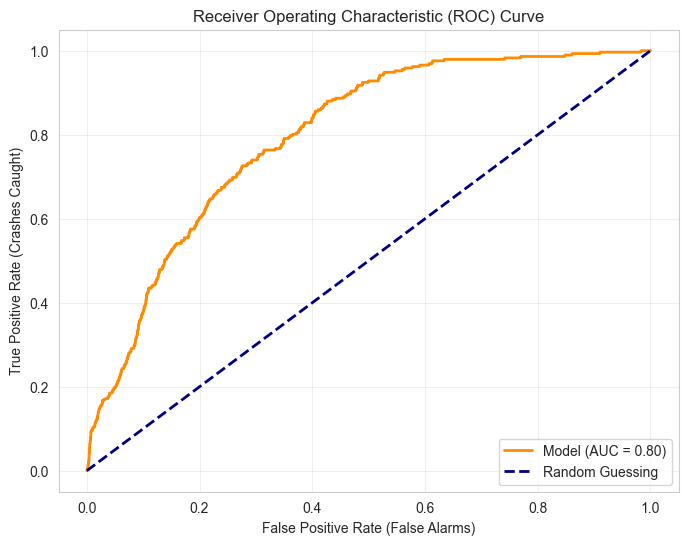


Sample Successful 'Bubble Bursts' Predicted:
      Date          Stock   Signal  Return_Next_Month
2020-03-09 NCLH UN Equity 0.774919          -0.447754
2020-03-10 TRGP UN Equity 0.861205          -0.305300
2020-03-10   BA UN Equity 0.800829          -0.438942
2020-03-11   BA UN Equity 0.879929          -0.314523
2020-03-13   BA UN Equity 0.855561          -0.401351
2020-03-13  RCL UN Equity 0.835820          -0.309310
2020-04-30 NCLH UN Equity 0.871580          -0.318293
2020-08-31 TSLA UW Equity 0.999292          -0.337354
2020-09-01 TSLA UW Equity 0.905638          -0.304894
2020-11-04 BIIB UW Equity 0.578282          -0.335658

[Grid Search] AUC across forward windows and crash thresholds...
FW=  5  CT= -0.05  AUC=0.579  Lift=1.51
FW=  5  CT= -0.10  AUC=0.650  Lift=2.12
FW=  5  CT= -0.15  AUC=0.692  Lift=2.48
FW=  5  CT= -0.20  AUC=0.716  Lift=2.64
FW=  5  CT= -0.30  AUC=0.797  Lift=3.77
FW= 10  CT= -0.05  AUC=0.557  Lift=1.30
FW= 10  CT= -0.10  AUC=0.612  Lift=1.82
FW= 10  CT= -0

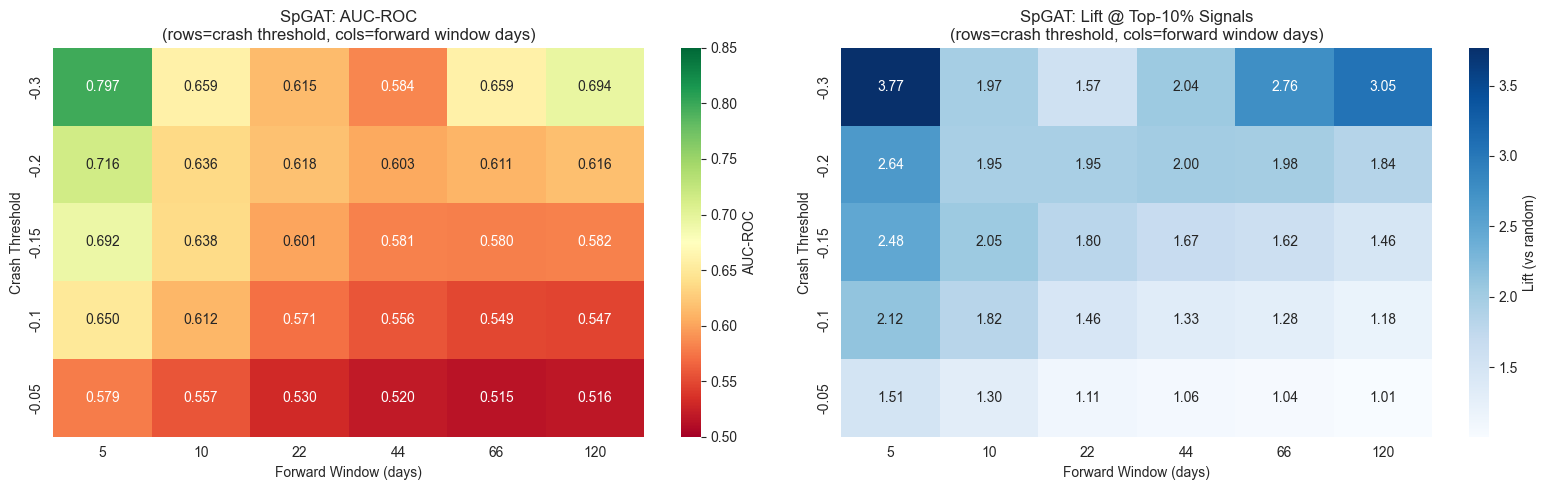


Best configuration:
ForwardWindow     5.000000
CrashThreshold   -0.300000
AUC               0.797097
Lift              3.767123
Baseline          0.000497


In [12]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_predictive_power(test_results, prices, forward_window=22, crash_threshold=-0.10):
    """
    Calculates accuracy by checking if high signals actually lead to price drops.
    
    Args:
        forward_window: Days to look ahead (e.g., 22 days = 1 month)
        crash_threshold: Return threshold to define a 'Real Crash' (e.g., -0.10 means -10% drop)
    """
    print("\n[Accuracy Evaluation] Calculating Predictive Power...")
    
    y_true = []   # 1 if stock actually crashed, 0 otherwise
    y_scores = [] # Your anomaly signal
    
    # List to track specific successful predictions for debugging
    successful_calls = []
    
    sorted_dates = sorted(list(test_results.keys()))
    
    # We stop early so we have enough data for the forward window
    valid_dates = [d for d in sorted_dates if d <= prices.index[-1] - pd.Timedelta(days=forward_window*1.5)]
    
    for t in valid_dates:
        stocks, signals = test_results[t]
        
        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()
        signals = signals.flatten()

        available = [s for s in stocks if s in prices.columns]
        if not available:
            continue
        mask = [i for i, s in enumerate(stocks) if s in available]
        signals = signals[mask]
        
        # Calculate Forward Returns for these stocks
        p_t = prices.loc[t, available]
        
        future_idx = prices.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if future_idx >= len(prices): continue
        future_date = prices.index[future_idx]
        p_future = prices.loc[future_date, available]
        
        fwd_returns = (p_future - p_t) / p_t
        is_crash = (fwd_returns < crash_threshold).astype(int)
        
        y_true.extend(is_crash.values)
        y_scores.extend(signals)
        
        df_eval = pd.DataFrame({'Stock': available, 'Signal': signals, 'Return': fwd_returns, 'Crash': is_crash})
        top_picks = df_eval.sort_values('Signal', ascending=False).head(5)
        
        for _, row in top_picks.iterrows():
            if row['Crash'] == 1:
                successful_calls.append({
                    'Date': t.strftime('%Y-%m-%d'),
                    'Stock': row['Stock'],
                    'Signal': row['Signal'],
                    'Return_Next_Month': row['Return']
                })

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    auc = roc_auc_score(y_true, y_scores)
    ic = np.corrcoef(y_scores, y_true)[0, 1]
    threshold_top_10 = np.percentile(y_scores, 90)
    high_signal_indices = y_scores > threshold_top_10
    precision_top_10 = np.mean(y_true[high_signal_indices])
    baseline_crash_rate = np.mean(y_true)
    lift = precision_top_10 / baseline_crash_rate if baseline_crash_rate > 0 else 0
    
    print("-" * 60)
    print(f"PREDICTIVE ACCURACY (Forward Window: {forward_window} days, Crash Threshold: {crash_threshold*100}%)")
    print("-" * 60)
    print(f"1. AUC-ROC Score:      {auc:.4f}  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)")
    print(f"2. Info Coefficient:   {ic:.4f}   (Correlation with actual crashes)")
    print(f"3. Precision (Top 10%):{precision_top_10:.2%} (Of highest signals, this % actually crashed)")
    print(f"4. Baseline Crash Rate:{baseline_crash_rate:.2%} (Random probability of a crash)")
    print(f"5. Model Lift:         {lift:.2f}x    (Model is {lift:.1f} times better than random guessing)")
    print("-" * 60)
    
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.2f})", color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
    plt.xlabel('False Positive Rate (False Alarms)')
    plt.ylabel('True Positive Rate (Crashes Caught)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    print("\nSample Successful 'Bubble Bursts' Predicted:")
    print(pd.DataFrame(successful_calls).head(10).to_string(index=False))


def evaluate_once(test_results, prices, forward_window, crash_threshold):
    """Single AUC evaluation for one (forward_window, crash_threshold) combo."""
    y_true, y_scores = [], []
    sorted_dates = sorted(test_results.keys())
    valid_dates = [d for d in sorted_dates if d <= prices.index[-1] - pd.Timedelta(days=forward_window)]

    for t in valid_dates:
        stocks, signals = test_results[t]
        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()
        signals = signals.flatten()

        available = [s for s in stocks if s in prices.columns]
        if not available:
            continue
        mask = [i for i, s in enumerate(stocks) if s in available]
        signals = signals[mask]

        p_t = prices.loc[t, available]
        future_idx = prices.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if future_idx >= len(prices):
            continue
        p_future = prices.loc[prices.index[future_idx], available]
        fwd_returns = (p_future - p_t) / p_t
        crash = (fwd_returns < crash_threshold).astype(int)

        y_true.extend(crash.values)
        y_scores.extend(signals)

    if len(y_true) == 0:
        return None

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    auc = roc_auc_score(y_true, y_scores)
    baseline = y_true.mean()
    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()
    lift = precision / baseline if baseline > 0 else np.nan
    return auc, lift, baseline


def grid_search(test_results, prices, forward_windows, crash_thresholds):
    """Sweep AUC over all (forward_window, crash_threshold) combinations."""
    rows = []
    for fw in forward_windows:
        for ct in crash_thresholds:
            result = evaluate_once(test_results, prices, fw, ct)
            if result is None:
                continue
            auc, lift, baseline = result
            rows.append({"ForwardWindow": fw, "CrashThreshold": ct,
                         "AUC": auc, "Lift": lift, "Baseline": baseline})
            print(f"FW={fw:3d}  CT={ct:6.2f}  AUC={auc:.3f}  Lift={lift:.2f}")
    return pd.DataFrame(rows)


# ==============================================================================
# EXECUTION
# ==============================================================================
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)
test_prices = prices.loc['2020-01-01':'2025-01-31']

# Single detailed evaluation
evaluate_predictive_power(results, test_prices, forward_window=5, crash_threshold=-0.30)

# Grid search over multiple forward windows and crash thresholds
forward_windows  = [5, 10, 22, 44, 66, 120]
crash_thresholds = [-0.05, -0.10, -0.15, -0.20, -0.30]

print("\n[Grid Search] AUC across forward windows and crash thresholds...")
df_grid = grid_search(results, test_prices, forward_windows, crash_thresholds)

# Pivot to heatmap format
auc_pivot  = df_grid.pivot(index="CrashThreshold", columns="ForwardWindow", values="AUC")
lift_pivot = df_grid.pivot(index="CrashThreshold", columns="ForwardWindow", values="Lift")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(auc_pivot, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.5, vmax=0.85, ax=axes[0],
            cbar_kws={"label": "AUC-ROC"})
axes[0].set_title("SpGAT: AUC-ROC\n(rows=crash threshold, cols=forward window days)")
axes[0].set_xlabel("Forward Window (days)")
axes[0].set_ylabel("Crash Threshold")

sns.heatmap(lift_pivot, annot=True, fmt=".2f", cmap="Blues",
            ax=axes[1], cbar_kws={"label": "Lift (vs random)"})
axes[1].set_title("SpGAT: Lift @ Top-10% Signals\n(rows=crash threshold, cols=forward window days)")
axes[1].set_xlabel("Forward Window (days)")
axes[1].set_ylabel("Crash Threshold")

plt.tight_layout()
plt.show()

print("\nBest configuration:")
print(df_grid.loc[df_grid["AUC"].idxmax()].to_string())


[8/6] Analyzing Regime Shifts & Contagion...

Systemic Risk Summary:
      Label  Danger_Pct  Stress_Index Top_Risk_Stock
Feb 01 2020    0.028169      1.813986 TSLA UW Equity
Feb 20 2020    0.026157      1.694942 MRNA UW Equity
Mar 01 2020    0.014085      1.492699 MRNA UW Equity
Mar 20 2020    0.020121      1.971148 AAPL UW Equity
Apr 15 2020    0.024145      1.726736  CCL UN Equity
Jun 01 2020    0.012072      1.393412 MRNA UW Equity
Sep 01 2020    0.012072      1.352118  CCL UN Equity
Nov 01 2020    0.006036      0.974723 NCLH UN Equity
Apr 15 2021    0.026157      1.754785 NCLH UN Equity
Apr 15 2022    0.018109      1.600490 HOOD UW Equity
Apr 15 2023    0.018109      1.821454 COIN UW Equity
Apr 15 2024    0.030242      2.050736 NVDA UW Equity


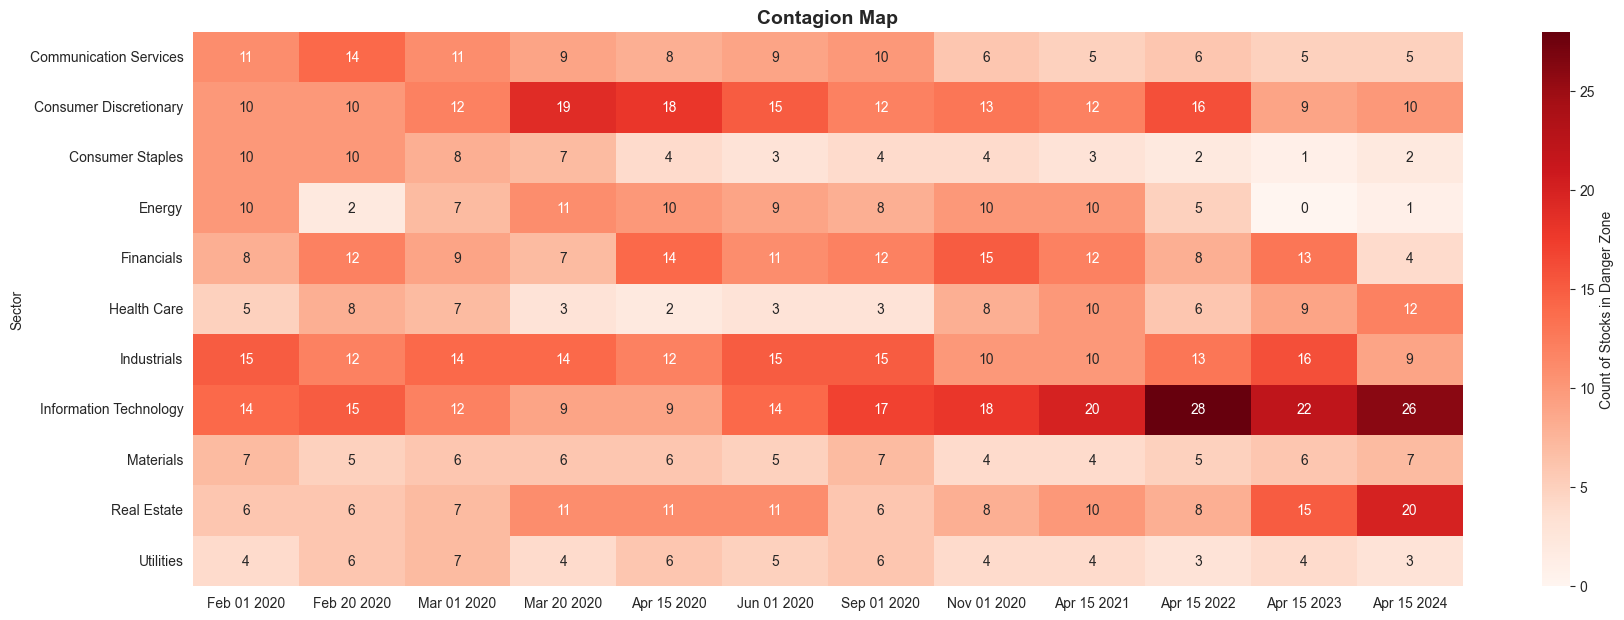

In [9]:
# ==============================================================================
# REGIME SHIFT & CONTAGION ANALYSIS
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                            header=0, index_col=0)
sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes

def get_nearest_date(target_date, available_dates):
    """Finds the nearest date in the available_dates list to the target_date."""
    target_ts = pd.to_datetime(target_date)
    nearest_date = min(available_dates, key=lambda x: abs(x - target_ts))
    days_diff = abs((nearest_date - target_ts).days)
    return nearest_date, days_diff

def calculate_systemic_risk_metrics(test_results, dates):
    """
    Computes systemic risk metrics for each date based on cluster distribution.
    """
    risk_metrics = []
    
    # We aggregate all signals first to ensure consistent global clustering
    # (In a real production system, you might retrain clusters daily, but for 
    # regime analysis, fixed cluster definitions help comparison)
    all_signals_concat = []
    for d in dates:
        nearest_date, _ = get_nearest_date(d, list(test_results.keys()))
        _, signals = test_results[nearest_date]
        if isinstance(signals, torch.Tensor): signals = signals.cpu().numpy()
        all_signals_concat.extend(signals.flatten())
        
    # Fit Global K-Means to define fixed "Risk Buckets"
    # This ensures "Cluster 9" means the same level of anomaly in 2020 and 2023
    global_kmeans = KMeans(n_clusters=5, random_state=42, n_init=5)
    global_kmeans.fit(np.array(all_signals_concat).reshape(-1, 1))
    
    # Sort centroids so Cluster 0 is low signal, Cluster 9 is high
    sorted_idx = np.argsort(global_kmeans.cluster_centers_.flatten())
    map_labels = {old: new for new, old in enumerate(sorted_idx)}
    
    for d in dates:
        nearest_date, _ = get_nearest_date(d, list(test_results.keys()))
        stocks, signals = test_results[nearest_date]
        if isinstance(signals, torch.Tensor): signals = signals.cpu().numpy()
        signals = signals.reshape(-1, 1)
        
        # Predict clusters using global definition
        raw_labels = global_kmeans.predict(signals)
        labels = np.array([map_labels[l] for l in raw_labels])
        
        df = pd.DataFrame({'Stock': stocks, 'Cluster': labels, 'Signal': signals.flatten()})
        
        # --- Metric 1: Risk Zone Saturation ---
        # Safe (0-1), Transition (2-3), Danger (4-5)
        safe_count = len(df[df['Cluster'] <= 1])
        trans_count = len(df[(df['Cluster'] > 1) & (df['Cluster'] <= 3)])
        danger_count = len(df[df['Cluster'] > 3])
        total = len(df)
        
        # --- Metric 2: Systemic Stress Index (Weighted Average Cluster) ---
        # Range 0.0 to 1.0 (normalized)
        stress_index = np.sum(df['Cluster'] * df['Signal']) / np.sum(df['Signal']) if np.sum(df['Signal']) > 0 else 0
        
        risk_metrics.append({
            'Date': nearest_date,
            'Label': d, # The label user asked for (e.g. "Pre-Covid")
            'Safe_Pct': safe_count / total,
            'Transition_Pct': trans_count / total,
            'Danger_Pct': danger_count / total,
            'Stress_Index': stress_index,
            'Top_Risk_Stock': df.sort_values('Signal', ascending=False).iloc[0]['Stock']
        })
        
    return pd.DataFrame(risk_metrics)

def plot_regime_shift_dashboard(risk_df, test_results, sectors_df):
    """
    Generates 3 Visualizations to analyze the regime shift.
    """
    sns.set_style("whitegrid")
    fig = plt.figure(figsize=(18, 12))
    
    # --- VIS 1: The "Risk Wave" (Stacked Area Chart) ---
    # Shows the saturation of the system over time
    #ax1 = plt.subplot(2, 2, 1)
    
    # Prepare data for stackplot
    dates_sorted = risk_df.sort_values('Date')
    #x = range(len(dates_sorted))
    # y1 = dates_sorted['Safe_Pct']
    # y2 = dates_sorted['Transition_Pct']
    # y3 = dates_sorted['Danger_Pct']
    
    # ax1.stackplot(x, y1, y2, y3, labels=['Safe Zone', 'Transition', 'Danger Zone'],
    #               colors=['#2ecc71', '#f1c40f', '#e74c3c'], alpha=0.8)
    
    # ax1.set_xticks(x)
    # ax1.set_xticklabels(dates_sorted['Label'], rotation=45)
    # ax1.set_title('Systemic Saturation: Migration to Danger Zones', fontsize=14, fontweight='bold')
    # ax1.set_ylabel('Proportion of Market', fontsize=12)
    # ax1.legend(loc='upper left')
    # ax1.grid(alpha=0.3)
    
    # --- VIS 2: Early Warning Signal (Stress Index) ---
    # ax2 = plt.subplot(2, 2, 2)
    
    # # Plot line
    # sns.lineplot(data=dates_sorted, x='Label', y='Stress_Index', marker='o', 
    #              linewidth=3, color='#e67e22', ax=ax2)
    
    # # Add thresholds
    # ax2.axhline(y=dates_sorted['Stress_Index'].mean(), color='grey', linestyle='--', label='Average Stress')
    
    # # Highlight the peak
    # peak = dates_sorted.loc[dates_sorted['Stress_Index'].idxmax()]
    # ax2.annotate('Regime Shift Peak', xy=(peak.name, peak['Stress_Index']), 
    #              xytext=(peak.name, peak['Stress_Index']+1),
    #              arrowprops=dict(facecolor='black', shrink=0.05))
    
    # ax2.set_title('Early Warning Signal: Systemic Stress Index', fontsize=14, fontweight='bold')
    # ax2.set_ylabel('Weighted Stress Score', fontsize=12)
    # ax2.set_xticklabels(dates_sorted['Label'], rotation=45)

    # --- VIS 3: Sector Contagion (Who is driving the Danger Zone?) ---
    ax3 = plt.subplot(2, 1, 2)
    
    # We want to see WHICH sectors are in the "Danger Zone" (Cluster > 6) during the crash dates
    crash_dates = risk_df[risk_df['Danger_Pct'] > 0.1]['Date'] # Filter for high risk dates
    
    if len(crash_dates) == 0:
        # Fallback if no high risk detected (unlikely in 2020)
        crash_dates = [risk_df.iloc[1]['Date']] 
        
    sector_risk_data = []
    
    # Re-extract data for these specific dates to map sectors
    # Note: This relies on the variables available in the global scope from your main script
    for d in risk_df['Date']:
        stocks, signals = test_results[d]
        if isinstance(signals, torch.Tensor): signals = signals.cpu().numpy()
        
        # Simple threshold for "High Anomaly" since we don't have the cluster labels stored in risk_df
        # We assume top 20% of signals are "Danger"
        threshold = np.percentile(signals, 80)
        high_risk_stocks = [s for s, sig in zip(stocks, signals.flatten()) if sig > threshold]
        
        # Map to sectors
        for s in high_risk_stocks:
            if s in sectors_df.index:
                # Assuming sectors_df has a column 'Sector' or similar mapping
                try:
                    sec = sectors_df.loc[s]['Sector']
                    if isinstance(sec, pd.Series): sec = sec.iloc[0]
                    sector_risk_data.append({'Date': d, 'Sector': sec, 'Count': 1})
                except:
                    pass

    if sector_risk_data:
        sec_df = pd.DataFrame(sector_risk_data)
        # Count high risk stocks per sector per date
        sec_pivot = sec_df.groupby(['Date', 'Sector']).size().unstack(fill_value=0)
        
        # Filter to match the labels we have
        sec_pivot = sec_pivot.reindex(risk_df['Date']).dropna(how='all')
        
        # Plot Heatmap
        sns.heatmap(sec_pivot.T, cmap='Reds', annot=True, fmt='d', ax=ax3, cbar_kws={'label': 'Count of Stocks in Danger Zone'})
        
        # Fix X labels to use user-friendly labels
        ax3.set_xticklabels(risk_df['Label'], rotation=0)
        ax3.set_xlabel('')
        ax3.set_title('Contagion Map', fontsize=14, fontweight='bold')
    else:
        ax3.text(0.5, 0.5, "Sector Data Not Available or No High Risk Stocks Found", 
                 ha='center', fontsize=14)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# EXECUTION
# ==============================================================================

# 1. Define the timeline with finer granularity around the crash for "Early Warning" detection
regime_dates = {
    '2020-02-01': 'Feb 01 2020',
    '2020-02-20': 'Feb 20 2020', # Adding this to capture the slide
    '2020-03-01': 'Mar 01 2020',
    '2020-03-20': 'Mar 20 2020',
    '2020-04-15': 'Apr 15 2020',
    '2020-06-01': 'Jun 01 2020',
    '2020-09-01': 'Sep 01 2020',
    '2020-11-01': 'Nov 01 2020',
    '2021-04-15': 'Apr 15 2021',
    '2022-04-15': 'Apr 15 2022',
    '2023-04-15': 'Apr 15 2023',
    '2024-04-15': 'Apr 15 2024',
}

# 2. Run Analysis
# Note: Requires 'test_results' and 'sectors' DataFrame from your main script

#if 'test_results' in locals() and 'sectors' in locals():
print("\n[8/6] Analyzing Regime Shifts & Contagion...")

# Calculate metrics
risk_df = calculate_systemic_risk_metrics(results, list(regime_dates.keys()))

# Map back the user friendly labels
risk_df['Label'] = risk_df['Label'].map(regime_dates)

# Print numerical summary
print("\nSystemic Risk Summary:")
print(risk_df[['Label', 'Danger_Pct', 'Stress_Index', 'Top_Risk_Stock']].to_string(index=False))

# Visualize
plot_regime_shift_dashboard(risk_df, results, sectors)
#else:
#    print("Error: Required data (test_results, sectors) not found.")

[5] Visualizing Average Anomaly Signal...


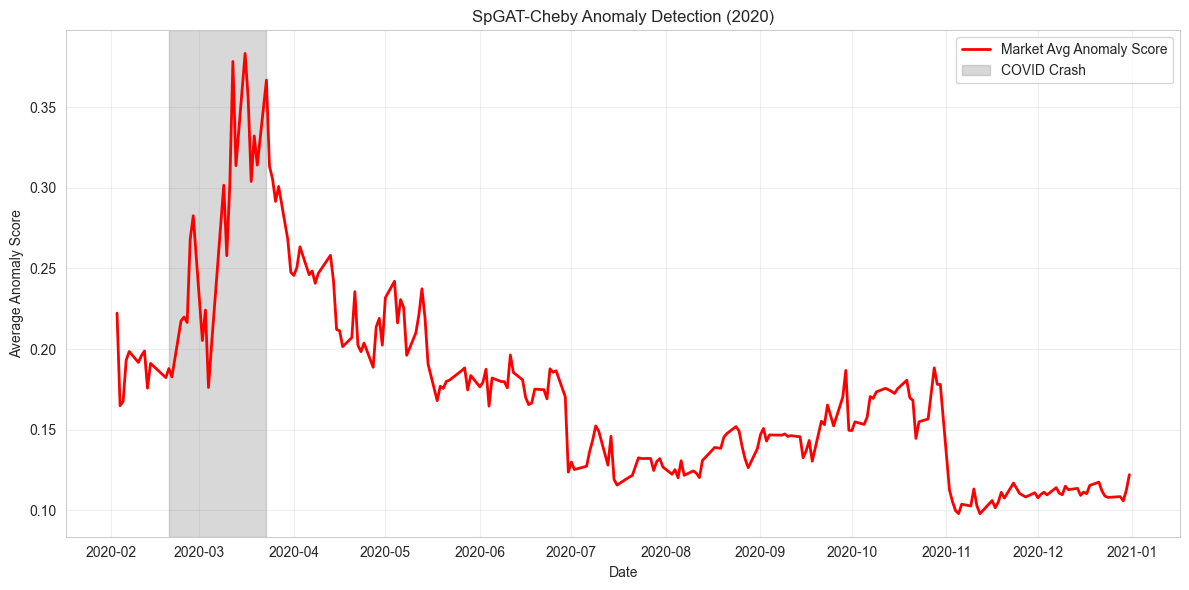

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the CSV with the correct date parsing options
# index_col=0 sets the first column (dates) as the index
# parse_dates=True converts those text dates into actual Timestamp objects
signals = pd.read_csv('spgat_bubble_signals.csv', index_col=0, parse_dates=True)

# 2. Filter for 2020 using Pandas slicing (instead of the invalid list syntax)
try:
    # .loc allows range slicing on DatetimeIndexes
    signals_2020 = signals.loc['2020-02-01':'2020-12-31']
except KeyError:
    print("Warning: Date range not found in data.")
    signals_2020 = pd.DataFrame()

if not signals_2020.empty:
    print("[5] Visualizing Average Anomaly Signal...")
    
    # 3. Calculate the Market Average (mean across all stocks/columns per row)
    avg_signals = signals_2020.mean(axis=1)
    
    plt.figure(figsize=(12, 6))
    
    # Plot directly using the index (dates) and values
    plt.plot(avg_signals.index, avg_signals.values, color='red', linewidth=2, label='Market Avg Anomaly Score')
    
    # Highlight COVID Crash
    plt.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'), 
                color='grey', alpha=0.3, label='COVID Crash')
    
    plt.title("SpGAT-Cheby Anomaly Detection (2020)")
    plt.ylabel("Average Anomaly Score")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 2020.")

[5] Visualizing Average Anomaly Signal...


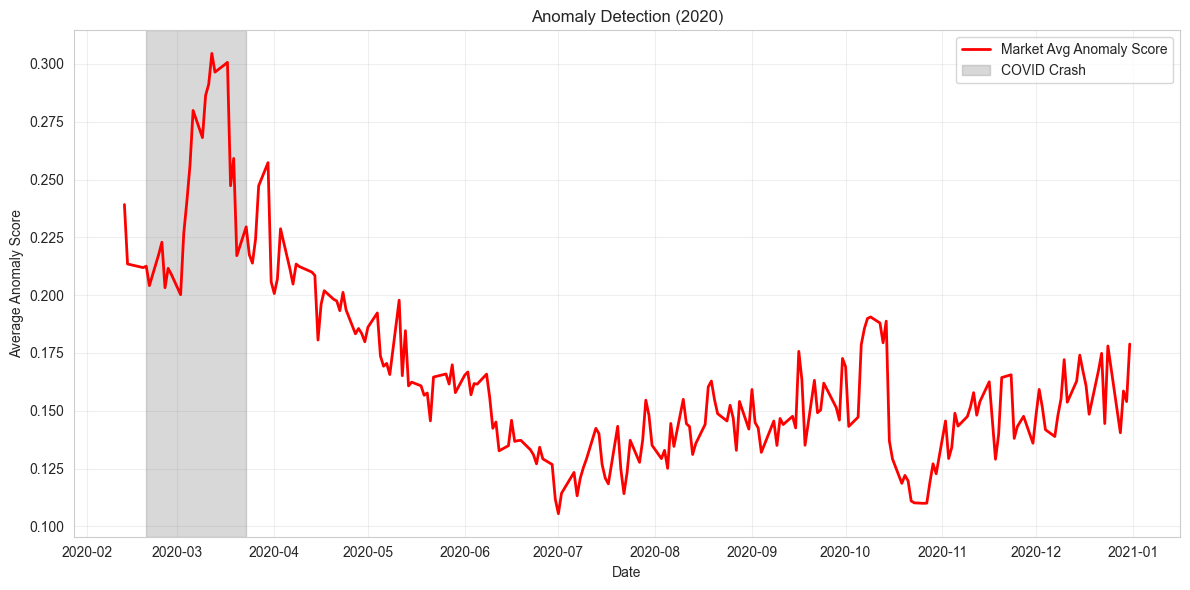

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the CSV with the correct date parsing options
# index_col=0 sets the first column (dates) as the index
# parse_dates=True converts those text dates into actual Timestamp objects
signals = pd.read_csv('outputs/bubble_signals_test.csv', index_col=0, parse_dates=True)

# 2. Filter for 2020 using Pandas slicing (instead of the invalid list syntax)
try:
    # .loc allows range slicing on DatetimeIndexes
    signals_2020 = signals.loc['2020-02-01':'2020-12-31']
except KeyError:
    print("Warning: Date range not found in data.")
    signals_2020 = pd.DataFrame()

if not signals_2020.empty:
    print("[5] Visualizing Average Anomaly Signal...")
    
    # 3. Calculate the Market Average (mean across all stocks/columns per row)
    avg_signals = signals_2020.mean(axis=1)
    
    plt.figure(figsize=(12, 6))
    
    # Plot directly using the index (dates) and values
    plt.plot(avg_signals.index, avg_signals.values, color='red', linewidth=2, label='Market Avg Anomaly Score')
    
    # Highlight COVID Crash
    plt.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'), 
                color='grey', alpha=0.3, label='COVID Crash')
    
    plt.title("Anomaly Detection (2020)")
    plt.ylabel("Average Anomaly Score")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 2020.")